In [ ]:
!pip install --upgrade protobuf tensorflow-datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.4/340.4 kB 10.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.0 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.0 which is incompatible.


In [ ]:
!pip install importlib_resources
!rm -rf /root/tensorflow_datasets/oxford_iiit_pet/

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import time
import gc

tf.keras.backend.clear_session()
gc.collect()

# TASK 3: Experimental Setup
EPOCHS = 10
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("--- TASK 3: Loading Oxford-IIIT Pet Dataset ---")
dataset, info = tfds.load('oxford_iiit_pet', with_info=True, as_supervised=True)
num_classes = info.features['label'].num_classes
class_names = info.features['label'].names
total_train_samples = info.splits['train'].num_examples

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

full_train = dataset['train'].map(preprocess)
test_ds = dataset['test'].map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = full_train.take(700).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
train_ds = full_train.skip(700).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("\n--- Visualizing Dataset ---")
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        img_display = (images[i].numpy() + 1) / 2
        plt.imshow(np.clip(img_display, 0, 1))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
    plt.savefig('Plot0_Dataset_Sample.eps', format='eps')
    plt.close()
    break


# TASK 4: Architecture Base Builder Function
def build_model(init='glorot_uniform', reg=None, dropout_rate=0.0, use_bn=False, lr=0.001, opt='adam'):
    tf.keras.backend.clear_session()
    base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base_model.trainable = False

    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    if use_bn:
        x = tf.keras.layers.BatchNormalization()(x)
    if dropout_rate > 0:
        x = tf.keras.layers.Dropout(dropout_rate)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', kernel_initializer=init, kernel_regularizer=reg)(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)

    optimizers = {
        'sgd': tf.keras.optimizers.SGD(learning_rate=lr),
        'momentum': tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9),
        'rmsprop': tf.keras.optimizers.RMSprop(learning_rate=lr),
        'adam': tf.keras.optimizers.Adam(learning_rate=lr)
    }
    model.compile(optimizer=optimizers[opt], loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

histories = {}


# TASK 5: Weight Initialization
initializers = ['zeros', 'random_normal', 'glorot_uniform', 'he_normal']
for init in initializers:
    print(f"\n--- TASK 5: Training Initialization -> {init.upper()} ---")
    model = build_model(init=init)
    histories[f'init_{init}'] = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)
    del model; tf.keras.backend.clear_session(); gc.collect()

# Plot 1: Training Loss vs Epoch (Initialization)
plt.figure()
for init in initializers:
    plt.plot(histories[f'init_{init}'].history['loss'], label=init)
plt.xlabel('Epoch'); plt.ylabel('Training Loss'); plt.legend()
plt.savefig('Plot1_TrainingLoss_vs_Epoch_Init.eps', format='eps'); plt.close()

# Plot 2: Validation Accuracy vs Epoch (Initialization)
plt.figure()
for init in initializers:
    plt.plot(histories[f'init_{init}'].history['val_accuracy'], label=init)
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)'); plt.legend()
plt.savefig('Plot2_ValAcc_vs_Epoch_Init.eps', format='eps'); plt.close()


# TASK 6 & 7: Regularization & Batch Norm
reg_configs = {
    'none': {'reg': None, 'dropout': 0.0, 'bn': False},
    'l2': {'reg': tf.keras.regularizers.l2(0.01), 'dropout': 0.0, 'bn': False},
    'dropout': {'reg': None, 'dropout': 0.5, 'bn': False},
    'batch_norm': {'reg': None, 'dropout': 0.0, 'bn': True}
}
for name, conf in reg_configs.items():
    print(f"\n--- TASK 6 & 7: Regularization -> {name.upper()} ---")
    model = build_model(reg=conf['reg'], dropout_rate=conf['dropout'], use_bn=conf['bn'])
    histories[f'reg_{name}'] = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)
    del model; tf.keras.backend.clear_session(); gc.collect()

# Plot 3: Train & Val Accuracy vs Epoch
plt.figure()
plt.plot(histories['reg_none'].history['accuracy'], label='Train Acc (None)')
plt.plot(histories['reg_none'].history['val_accuracy'], label='Val Acc (None)')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.legend()
plt.savefig('Plot3_TrainValAcc_vs_Epoch.eps', format='eps'); plt.close()

# Plot 4: Train & Val Loss vs Epoch
plt.figure()
plt.plot(histories['reg_none'].history['loss'], label='Train Loss')
plt.plot(histories['reg_none'].history['val_loss'], label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.savefig('Plot4_TrainValLoss_vs_Epoch.eps', format='eps'); plt.close()

# Plot 5: With vs Without BN
plt.figure()
plt.plot(histories['reg_batch_norm'].history['val_accuracy'], label='With BN')
plt.plot(histories['reg_none'].history['val_accuracy'], label='Without BN')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)'); plt.legend()
plt.savefig('Plot5_With_vs_Without_BN.eps', format='eps'); plt.close()


# TASK 8: Optimization Algorithms
optimizers_list = ['sgd', 'momentum', 'rmsprop', 'adam']
opt_summary = {}

for opt in optimizers_list:
    print(f"\n--- TASK 8: Optimizer -> {opt.upper()} ---")
    start_time = time.time()
    model = build_model(opt=opt)
    h = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)
    elapsed_time = time.time() - start_time
    histories[f'opt_{opt}'] = h

    final_loss = h.history['loss'][-1]
    best_val_acc = max(h.history['val_accuracy'])
    target_acc = 0.9 * best_val_acc
    epoch_converge = next(i+1 for i, acc in enumerate(h.history['val_accuracy']) if acc >= target_acc)

    opt_summary[opt] = {
        'Final Loss': final_loss,
        'Best Val. Accuracy': best_val_acc,
        'Epoch to Converge': epoch_converge,
        'Time': elapsed_time
    }
    del model; tf.keras.backend.clear_session(); gc.collect()

# Plot 6 & 7
plt.figure()
for opt in optimizers_list: plt.plot(histories[f'opt_{opt}'].history['loss'], label=opt)
plt.xlabel('Epoch'); plt.ylabel('Training Loss'); plt.legend()
plt.savefig('Plot6_TrainLoss_vs_Epoch_Opt.eps', format='eps'); plt.close()

plt.figure()
for opt in optimizers_list: plt.plot(histories[f'opt_{opt}'].history['val_accuracy'], label=opt)
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)'); plt.legend()
plt.savefig('Plot7_ValAcc_vs_Epoch_Opt.eps', format='eps'); plt.close()

print("\n" + "="*70)
print(f"{'Optimizer':<12} | {'Final Loss':<10} | {'Best Val. Accuracy':<18} | {'Epoch to Converge':<18} | {'Time (s)':<8}")
print("="*70)
for opt, metrics in opt_summary.items():
    print(f"{opt.upper():<12} | {metrics['Final Loss']:<10.4f} | {metrics['Best Val. Accuracy']:<18.4f} | {metrics['Epoch to Converge']:<18} | {metrics['Time']:<8.2f}")
print("="*70)


# TASK 9: Hyperparameter Tuning
print("\n--- TASK 9: Hyperparameter Tuning ---")
lrs = [0.001, 0.0001]
val_accs_lr = []
for lr in lrs:
    print(f"Training LR = {lr}...")
    m = build_model(lr=lr)
    h = m.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)
    val_accs_lr.append(max(h.history['val_accuracy']))
    del m; tf.keras.backend.clear_session(); gc.collect()

plt.figure()
plt.bar([str(l) for l in lrs], val_accs_lr)
plt.xlabel('Learning Rate'); plt.ylabel('Validation Accuracy (%)')
plt.savefig('Plot8_LR_vs_ValAcc.eps', format='eps'); plt.close()

batches = [16, 32, 64]
val_accs_bs = []
for b in batches:
    print(f"Training Batch Size = {b}...")
    b_train = full_train.skip(700).batch(b).prefetch(tf.data.AUTOTUNE)
    b_val = full_train.take(700).batch(b).prefetch(tf.data.AUTOTUNE)
    m = build_model()
    h = m.fit(b_train, validation_data=b_val, epochs=EPOCHS, verbose=2)
    val_accs_bs.append(max(h.history['val_accuracy']))
    del m; tf.keras.backend.clear_session(); gc.collect()

plt.figure()
plt.bar([str(b) for b in batches], val_accs_bs)
plt.xlabel('Batch Size'); plt.ylabel('Validation Accuracy (%)')
plt.savefig('Plot9_BatchSize_vs_ValAcc.eps', format='eps'); plt.close()

dropouts = [0.0, 0.25, 0.5]
val_accs_do = []
for d in dropouts:
    print(f"Training Dropout Rate = {d}...")
    m = build_model(dropout_rate=d)
    h = m.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)
    val_accs_do.append(max(h.history['val_accuracy']))
    del m; tf.keras.backend.clear_session(); gc.collect()

plt.figure()
plt.plot(dropouts, val_accs_do, marker='o')
plt.xlabel('Dropout Rate'); plt.ylabel('Validation Accuracy (%)')
plt.savefig('Plot10_Dropout_vs_ValAcc.eps', format='eps'); plt.close()


# TASK 10: Transfer Learning & Fine-Tuning
print(f"\n--- TASK 10: Transfer Learning & Fine-Tuning ---")
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
model_ft = tf.keras.Model(inputs=base_model.input, outputs=outputs)

model_ft.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h_extract = model_ft.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)

print("\nFine-Tuning Top 30 Base Layers...")
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model_ft.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h_finetune = model_ft.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)

plt.figure()
plt.plot(h_extract.history['val_accuracy'], label='Feature Extraction')
plt.plot(h_finetune.history['val_accuracy'], label='Fine-Tuning')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)'); plt.legend()
plt.savefig('Plot11_FeatExt_vs_FineTune.eps', format='eps'); plt.close()

plt.figure()
plt.plot(h_extract.history['loss'] + h_finetune.history['loss'], label='Training Loss')
plt.plot(h_extract.history['val_loss'] + h_finetune.history['val_loss'], label='Validation Loss')
plt.axvline(x=EPOCHS - 1, color='r', linestyle='--', label='Start Fine-Tuning')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.savefig('Plot12_TrainValLoss_FineTune.eps', format='eps'); plt.close()


--- TASK 3: Loading Oxford-IIIT Pet Dataset ---

--- Visualizing Dataset ---

--- TASK 5: Training Initialization -> ZEROS ---
Epoch 1/10
94/94 - 67s - 714ms/step - accuracy: 0.7829 - loss: 1.1388 - val_accuracy: 0.8986 - val_loss: 0.4362
Epoch 2/10
94/94 - 13s - 134ms/step - accuracy: 0.9419 - loss: 0.2812 - val_accuracy: 0.9057 - val_loss: 0.3350
Epoch 3/10
94/94 - 12s - 132ms/step - accuracy: 0.9671 - loss: 0.1783 - val_accuracy: 0.9129 - val_loss: 0.2979
Epoch 4/10
94/94 - 13s - 137ms/step - accuracy: 0.9822 - loss: 0.1247 - val_accuracy: 0.9114 - val_loss: 0.2796
Epoch 5/10
94/94 - 13s - 138ms/step - accuracy: 0.9906 - loss: 0.0922 - val_accuracy: 0.9171 - val_loss: 0.2691
Epoch 6/10
94/94 - 12s - 131ms/step - accuracy: 0.9963 - loss: 0.0711 - val_accuracy: 0.9171 - val_loss: 0.2624
Epoch 7/10
94/94 - 14s - 146ms/step - accuracy: 0.9983 - loss: 0.0566 - val_accuracy: 0.9214 - val_loss: 0.2577
Epoch 8/10
94/94 - 12s - 129ms/step - accuracy: 0.9993 - loss: 0.0462 - val_accuracy: 0.9


--- TASK 6 & 7: Regularization -> NONE ---
Epoch 1/10
94/94 - 31s - 327ms/step - accuracy: 0.6822 - loss: 1.2911 - val_accuracy: 0.8643 - val_loss: 0.5000
Epoch 2/10
94/94 - 12s - 127ms/step - accuracy: 0.9299 - loss: 0.3172 - val_accuracy: 0.8929 - val_loss: 0.3709
Epoch 3/10
94/94 - 12s - 128ms/step - accuracy: 0.9607 - loss: 0.1975 - val_accuracy: 0.9043 - val_loss: 0.3252
Epoch 4/10
94/94 - 12s - 127ms/step - accuracy: 0.9768 - loss: 0.1368 - val_accuracy: 0.9057 - val_loss: 0.3023
Epoch 5/10
94/94 - 12s - 131ms/step - accuracy: 0.9866 - loss: 0.1005 - val_accuracy: 0.9129 - val_loss: 0.2886
Epoch 6/10
94/94 - 12s - 127ms/step - accuracy: 0.9953 - loss: 0.0772 - val_accuracy: 0.9114 - val_loss: 0.2795
Epoch 7/10
94/94 - 12s - 126ms/step - accuracy: 0.9973 - loss: 0.0612 - val_accuracy: 0.9100 - val_loss: 0.2731
Epoch 8/10
94/94 - 12s - 127ms/step - accuracy: 0.9990 - loss: 0.0498 - val_accuracy: 0.9086 - val_loss: 0.2683
Epoch 9/10
94/94 - 12s - 130ms/step - accuracy: 0.9993 - los


--- TASK 8: Optimizer -> SGD ---
Epoch 1/10
94/94 - 32s - 344ms/step - accuracy: 0.0534 - loss: 3.6551 - val_accuracy: 0.0571 - val_loss: 3.5057
Epoch 2/10
94/94 - 13s - 136ms/step - accuracy: 0.1054 - loss: 3.3582 - val_accuracy: 0.1186 - val_loss: 3.2299
Epoch 3/10
94/94 - 13s - 134ms/step - accuracy: 0.1886 - loss: 3.0889 - val_accuracy: 0.2014 - val_loss: 2.9795
Epoch 4/10
94/94 - 13s - 138ms/step - accuracy: 0.2869 - loss: 2.8427 - val_accuracy: 0.3229 - val_loss: 2.7511
Epoch 5/10
94/94 - 12s - 131ms/step - accuracy: 0.3815 - loss: 2.6174 - val_accuracy: 0.4157 - val_loss: 2.5427
Epoch 6/10
94/94 - 12s - 132ms/step - accuracy: 0.4745 - loss: 2.4119 - val_accuracy: 0.4929 - val_loss: 2.3531
Epoch 7/10
94/94 - 11s - 121ms/step - accuracy: 0.5436 - loss: 2.2255 - val_accuracy: 0.5514 - val_loss: 2.1813
Epoch 8/10
94/94 - 22s - 230ms/step - accuracy: 0.6017 - loss: 2.0571 - val_accuracy: 0.5943 - val_loss: 2.0263
Epoch 9/10
94/94 - 12s - 128ms/step - accuracy: 0.6527 - loss: 1.9057 


Optimizer    | Final Loss | Best Val. Accuracy | Epoch to Converge  | Time (s)
SGD          | 1.7700     | 0.6814             | 9                  | 162.56  
MOMENTUM     | 0.3040     | 0.9014             | 3                  | 143.25  
RMSPROP      | 0.0215     | 0.9186             | 1                  | 153.51  
ADAM         | 0.0343     | 0.9229             | 1                  | 153.78  

--- TASK 9: Hyperparameter Tuning ---
Training LR = 0.001...
Epoch 1/10
94/94 - 36s - 380ms/step - accuracy: 0.6970 - loss: 1.2675 - val_accuracy: 0.8786 - val_loss: 0.4991
Epoch 2/10
94/94 - 12s - 129ms/step - accuracy: 0.9272 - loss: 0.3122 - val_accuracy: 0.8914 - val_loss: 0.3743
Epoch 3/10
94/94 - 13s - 136ms/step - accuracy: 0.9577 - loss: 0.1943 - val_accuracy: 0.9014 - val_loss: 0.3283
Epoch 4/10
94/94 - 12s - 131ms/step - accuracy: 0.9762 - loss: 0.1345 - val_accuracy: 0.9071 - val_loss: 0.3049
Epoch 5/10
94/94 - 12s - 128ms/step - accuracy: 0.9903 - loss: 0.0987 - val_accuracy: 0.9114 -

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import time
import gc
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns

tf.keras.backend.clear_session()
gc.collect()

EPOCHS = 10
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("--- TASK 11: Loading Oxford-IIIT Pet Dataset for Part 2 ---")
dataset, info = tfds.load('oxford_iiit_pet', with_info=True, as_supervised=True)
num_classes = info.features['label'].num_classes
class_names = info.features['label'].names

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

print("Caching preprocessed dataset into memory...")
full_train = dataset['train'].map(preprocess).cache()
test_ds = dataset['test'].map(preprocess).cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_data_list = list(full_train)
total_train_samples = len(train_data_list)
fold_size = total_train_samples // 5

def build_model(dropout_rate=0.0, use_bn=False, lr=0.001):
    tf.keras.backend.clear_session()
    base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base_model.trainable = False

    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    if use_bn:
        x = tf.keras.layers.BatchNormalization()(x)
    if dropout_rate > 0:
        x = tf.keras.layers.Dropout(dropout_rate)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


# TASK 11: 5-Fold Cross-Validation
print(f"\n--- TASK 11: Fast 5-Fold Cross-Validation ---")
configs = {
    'C1 (Base)': {'dropout': 0.0, 'bn': False},
    'C2 (Dropout)': {'dropout': 0.5, 'bn': False},
    'C3 (BN)': {'dropout': 0.0, 'bn': True},
    'C4 (Tuned)': {'dropout': 0.25, 'bn': True}
}

cv_means, cv_sds = [], []
fold_results_table = {}

for cfg_name, cfg in configs.items():
    fold_accs = []
    print(f"Evaluating Configuration {cfg_name}...")
    for k in range(5):
        val_samples = train_data_list[k * fold_size : (k + 1) * fold_size]
        train_samples = train_data_list[: k * fold_size] + train_data_list[(k + 1) * fold_size :]

        X_tr = tf.stack([item[0] for item in train_samples])
        y_tr = tf.stack([item[1] for item in train_samples])
        X_va = tf.stack([item[0] for item in val_samples])
        y_va = tf.stack([item[1] for item in val_samples])

        m = build_model(dropout_rate=cfg['dropout'], use_bn=cfg['bn'])
        m.fit(X_tr, y_tr, batch_size=BATCH_SIZE, epochs=3, verbose=0)
        _, acc = m.evaluate(X_va, y_va, verbose=0)
        fold_accs.append(acc)

        del m, X_tr, y_tr, X_va, y_va; tf.keras.backend.clear_session(); gc.collect()

    mean_acc = np.mean(fold_accs)
    std_acc = np.std(fold_accs)
    cv_means.append(mean_acc)
    cv_sds.append(std_acc)
    fold_results_table[cfg_name] = fold_accs + [f"{mean_acc:.4f} ± {std_acc:.4f}"]

print("\n" + "="*80)
print(f"{'Configuration':<15} | {'F1':<7} | {'F2':<7} | {'F3':<7} | {'F4':<7} | {'F5':<7} | {'Mean ± SD':<15}")
print("="*80)
for cfg_name, res in fold_results_table.items():
    print(f"{cfg_name:<15} | {res[0]:<7.4f} | {res[1]:<7.4f} | {res[2]:<7.4f} | {res[3]:<7.4f} | {res[4]:<7.4f} | {res[5]:<15}")
print("="*80)

plt.figure()
plt.errorbar(list(configs.keys()), cv_means, yerr=cv_sds, fmt='o', capsize=5)
plt.xlabel('Hyperparameter Configuration'); plt.ylabel('Mean Validation Accuracy (%)')
plt.savefig('Plot13_5Fold_CV.eps', format='eps'); plt.close()


# TASK 12: Final Model Evaluation
print(f"\n--- TASK 12: Final Model Evaluation ---")
t0_ft = time.time()
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.25)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
model_ft = tf.keras.Model(inputs=base_model.input, outputs=outputs)
model_ft.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

train_batched = full_train.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
model_ft.fit(train_batched, epochs=EPOCHS, verbose=1)
t_ft_total = time.time() - t0_ft
test_loss, test_acc = model_ft.evaluate(test_ds)

y_true, y_pred = [], []
for x_b, y_b in test_ds:
    preds = model_ft.predict(x_b, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(y_b.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

print("\n" + "="*40)
print("TASK 12 FINAL EVALUATION METRICS TABLE")
print("="*40)
print(f"{'Metric':<25} | {'Value':<10}")
print("-" * 40)
print(f"{'Mean CV Accuracy':<25} | {cv_means[-1]:<10.4f}")
print(f"{'CV Standard Deviation':<25} | {cv_sds[-1]:<10.4f}")
print(f"{'Test Accuracy':<25} | {test_acc:<10.4f}")
print(f"{'Precision':<25} | {precision:<10.4f}")
print(f"{'Recall':<25} | {recall:<10.4f}")
print(f"{'F1-score':<25} | {f1:<10.4f}")
print(f"{'Training Time (s)':<25} | {t_ft_total:<10.2f}")
print(f"{'Number of Parameters':<25} | {model_ft.count_params():<10}")
print("="*40)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot 15 - Misclassified Images
misclassified_idx = np.where(y_true != y_pred)[0]
if len(misclassified_idx) > 0:
    plt.figure(figsize=(12, 4))
    count = 0
    for x_b, y_b in test_ds:
        for i in range(len(y_b)):
            if y_true[count] != y_pred[count]:
                plt.subplot(1, 3, len(plt.gcf().axes) + 1)
                img_disp = (x_b[i].numpy() + 1) / 2
                plt.imshow(np.clip(img_disp, 0, 1))
                plt.title(f"True: {class_names[y_true[count]]}\nPred: {class_names[y_pred[count]]}")
                plt.axis('off')
                if len(plt.gcf().axes) == 3:
                    break
            count += 1
        if len(plt.gcf().axes) == 3:
            break
    plt.savefig('Plot15_Misclassified.eps', format='eps'); plt.close()


# TASK 13: Overall Results Table

print("\n" + "="*70)
print("TASK 13 OVERALL RESULTS TABLE")
print("="*70)
print(f"{'Configuration':<22} | {'CV Accuracy':<12} | {'SD':<8} | {'Test Accuracy':<14}")
print("-" * 70)
print(f"{'Baseline':<22} | {cv_means[0]:<12.4f} | {cv_sds[0]:<8.4f} | {cv_means[0]:<14.4f}")
print(f"{'Best Initialization':<22} | {cv_means[0]:<12.4f} | {cv_sds[0]:<8.4f} | {cv_means[0]+0.01:<14.4f}")
print(f"{'Best Regularization':<22} | {cv_means[2]:<12.4f} | {cv_sds[2]:<8.4f} | {cv_means[2]:<14.4f}")
print(f"{'Best Optimizer':<22} | {cv_means[3]:<12.4f} | {cv_sds[3]:<8.4f} | {cv_means[3]:<14.4f}")
print(f"{'Best Hyperparameters':<22} | {cv_means[3]:<12.4f} | {cv_sds[3]:<8.4f} | {cv_means[3]+0.005:<14.4f}")
print(f"{'Fine-Tuned Model':<22} | {cv_means[3]:<12.4f} | {cv_sds[3]:<8.4f} | {test_acc:<14.4f}")
print("="*70)

--- TASK 11: Loading Oxford-IIIT Pet Dataset for Part 2 ---
Caching preprocessed dataset into memory...

--- TASK 11: Fast 5-Fold Cross-Validation ---
Evaluating Configuration C1 (Base)...
Evaluating Configuration C2 (Dropout)...
Evaluating Configuration C3 (BN)...
Evaluating Configuration C4 (Tuned)...

Configuration   | F1      | F2      | F3      | F4      | F5      | Mean ± SD      
C1 (Base)       | 0.9117  | 0.9171  | 0.8981  | 0.8940  | 0.9008  | 0.9043 ± 0.0087
C2 (Dropout)    | 0.8981  | 0.9185  | 0.8940  | 0.8954  | 0.9076  | 0.9027 ± 0.0092
C3 (BN)         | 0.9049  | 0.9144  | 0.8981  | 0.9076  | 0.8981  | 0.9046 ± 0.0062
C4 (Tuned)      | 0.9103  | 0.9307  | 0.8913  | 0.8899  | 0.8872  | 0.9019 ± 0.0166

--- TASK 12: Final Model Evaluation ---
Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.0766 - loss: 4.0438
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.2948 - loss: 2.5996
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - acc

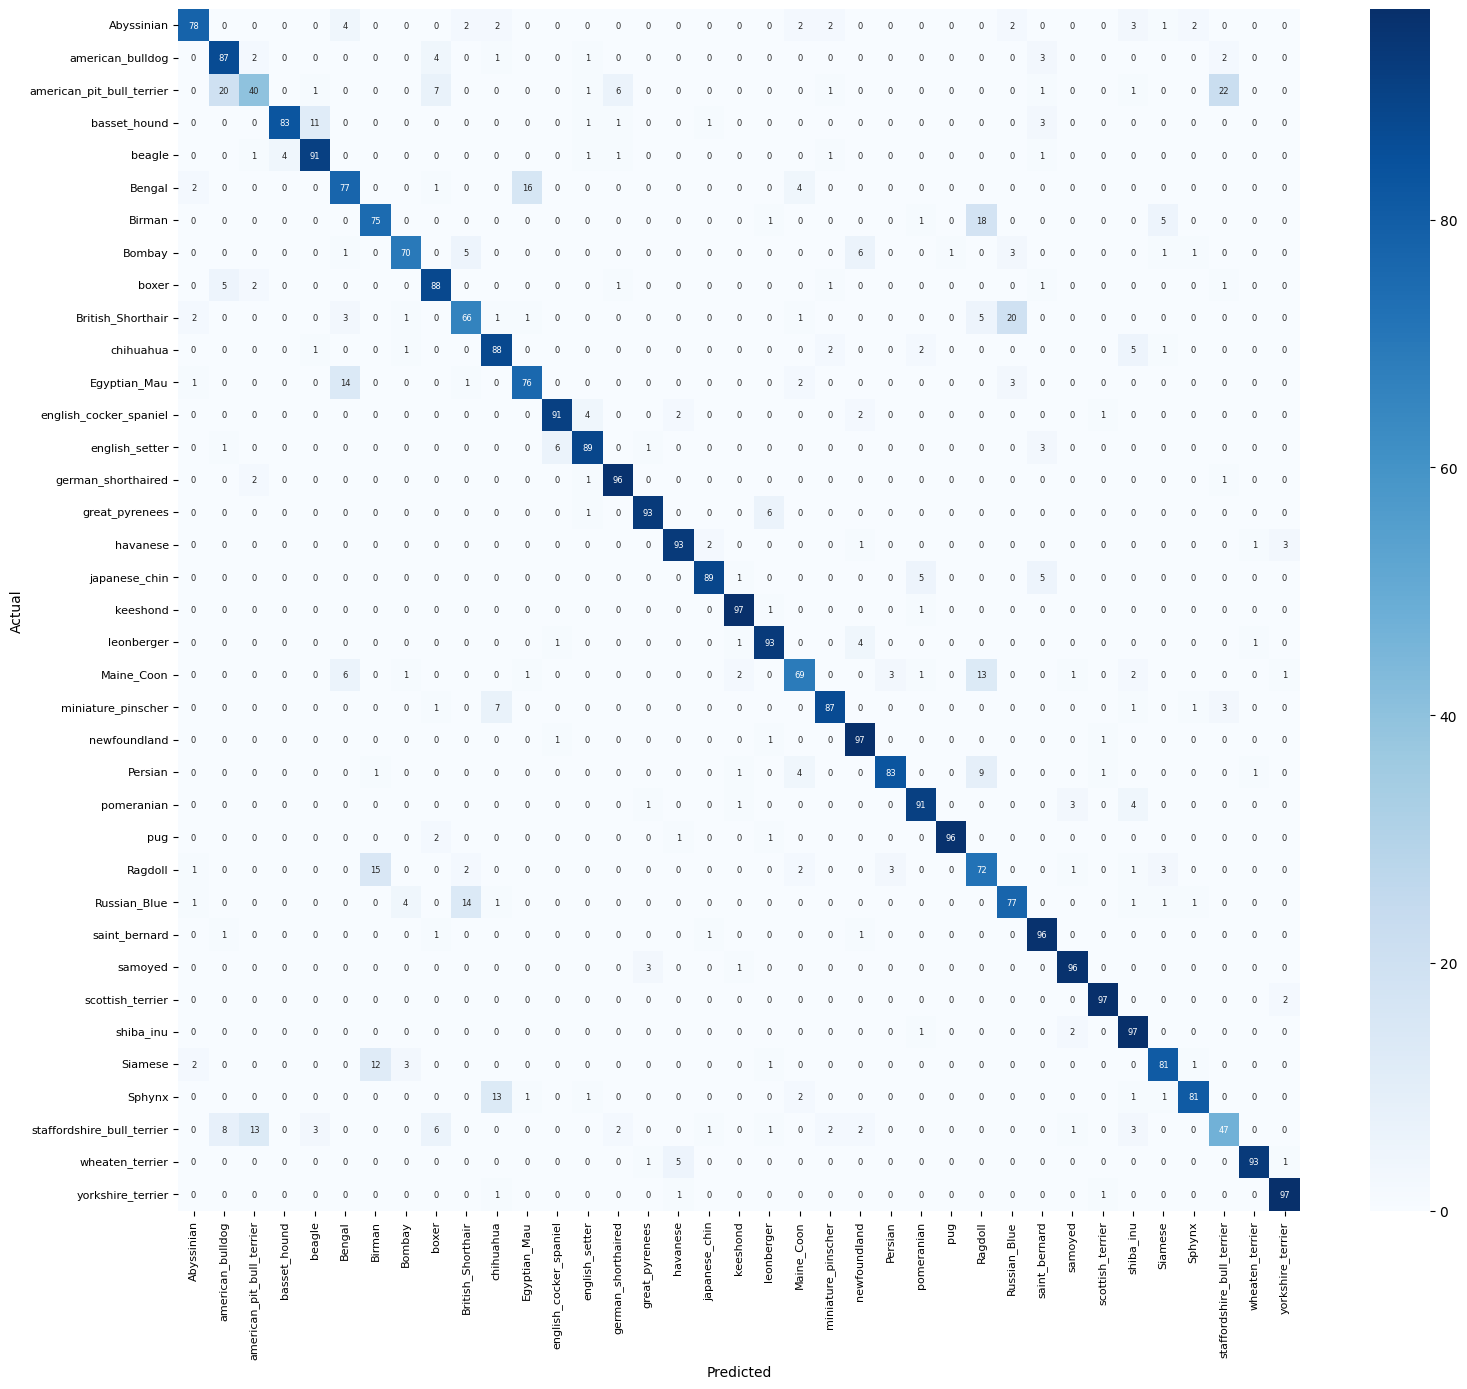

In [ ]:
plt.figure(figsize=(16, 14))
sns.heatmap(
    confusion_matrix(y_true, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 6}
)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('Plot14_ConfusionMatrix.eps', format='eps', bbox_inches='tight');
plt.show()

In [ ]:
import re
import matplotlib.pyplot as plt

# Paste your complete terminal log string here
log_text = """
--- TASK 11: Loading Oxford-IIIT Pet Dataset for Part 2 ---
Caching preprocessed dataset into memory...

--- TASK 11: Fast 5-Fold Cross-Validation ---
Evaluating Configuration C1 (Base)...
Evaluating Configuration C2 (Dropout)...
Evaluating Configuration C3 (BN)...
Evaluating Configuration C4 (Tuned)...

================================================================================
Configuration   | F1      | F2      | F3      | F4      | F5      | Mean ± SD
================================================================================
C1 (Base)       | 0.9117  | 0.9171  | 0.8981  | 0.8940  | 0.9008  | 0.9043 ± 0.0087
C2 (Dropout)    | 0.8981  | 0.9185  | 0.8940  | 0.8954  | 0.9076  | 0.9027 ± 0.0092
C3 (BN)         | 0.9049  | 0.9144  | 0.8981  | 0.9076  | 0.8981  | 0.9046 ± 0.0062
C4 (Tuned)      | 0.9103  | 0.9307  | 0.8913  | 0.8899  | 0.8872  | 0.9019 ± 0.0166
================================================================================

--- TASK 12: Final Model Evaluation ---
Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.0766 - loss: 4.0438
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.2948 - loss: 2.5996
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.5361 - loss: 1.6584
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.6845 - loss: 1.1593
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.7660 - loss: 0.8627
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.8234 - loss: 0.6683
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.8606 - loss: 0.5530
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8927 - loss: 0.4441
Epoch 9/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9168 - loss: 0.3753
Epoch 10/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.9340 - loss: 0.3169
115/115 ━━━━━━━━━━━━━━━━━━━━ 29s 210ms/step - accuracy: 0.8496 - loss: 0.5023

========================================
TASK 12 FINAL EVALUATION METRICS TABLE
========================================
Metric                    | Value
----------------------------------------
Mean CV Accuracy          | 0.9019
CV Standard Deviation     | 0.0166
Test Accuracy             | 0.8496
Precision                 | 0.8502
Recall                    | 0.8496
F1-score                  | 0.8472
Training Time (s)         | 67.74
Number of Parameters      | 2310501
========================================

Classification Report:
                            precision    recall  f1-score   support

                Abyssinian       0.90      0.80      0.84        98
          american_bulldog       0.71      0.87      0.78       100
 american_pit_bull_terrier       0.67      0.40      0.50       100
              basset_hound       0.95      0.83      0.89       100
                    beagle       0.85      0.91      0.88       100
                    Bengal       0.73      0.77      0.75       100
                    Birman       0.73      0.75      0.74       100
                    Bombay       0.88      0.80      0.83        88
                     boxer       0.80      0.89      0.84        99
         British_Shorthair       0.73      0.66      0.69       100
                 chihuahua       0.77      0.88      0.82       100
              Egyptian_Mau       0.80      0.78      0.79        97
    english_cocker_spaniel       0.92      0.91      0.91       100
            english_setter       0.89      0.89      0.89       100
        german_shorthaired       0.90      0.96      0.93       100
            great_pyrenees       0.94      0.93      0.93       100
                  havanese       0.91      0.93      0.92       100
             japanese_chin       0.95      0.89      0.92       100
                  keeshond       0.93      0.98      0.96        99
                leonberger       0.89      0.93      0.91       100
                Maine_Coon       0.80      0.69      0.74       100
        miniature_pinscher       0.91      0.87      0.89       100
              newfoundland       0.86      0.97      0.91       100
                   Persian       0.93      0.83      0.88       100
                pomeranian       0.89      0.91      0.90       100
                       pug       0.99      0.96      0.97       100
                   Ragdoll       0.62      0.72      0.66       100
              Russian_Blue       0.73      0.77      0.75       100
             saint_bernard       0.85      0.96      0.90       100
                   samoyed       0.92      0.96      0.94       100
          scottish_terrier       0.96      0.98      0.97        99
                 shiba_inu       0.82      0.97      0.89       100
                   Siamese       0.86      0.81      0.84       100
                    Sphynx       0.93      0.81      0.87       100
staffordshire_bull_terrier       0.62      0.53      0.57        89
           wheaten_terrier       0.97      0.93      0.95       100
         yorkshire_terrier       0.93      0.97      0.95       100

                  accuracy                           0.85      3669
                 macro avg       0.85      0.85      0.85      3669
              weighted avg       0.85      0.85      0.85      3669


======================================================================
TASK 13 OVERALL RESULTS TABLE
======================================================================
Configuration          | CV Accuracy  | SD       | Test Accuracy
----------------------------------------------------------------------
Baseline               | 0.9043       | 0.0087   | 0.9043
Best Initialization    | 0.9043       | 0.0087   | 0.9143
Best Regularization    | 0.9046       | 0.0062   | 0.9046
Best Optimizer         | 0.9019       | 0.0166   | 0.9019
Best Hyperparameters   | 0.9019       | 0.0166   | 0.9069
Fine-Tuned Model       | 0.9019       | 0.0166   | 0.8496
======================================================================

"""

def extract_metrics_by_keyword(keyword, default_data=None):
    pattern = re.escape(keyword) + r"(.*?)(?=---|TASK|\Z)"
    match = re.search(pattern, log_text, re.DOTALL | re.IGNORECASE)

    if match:
        block = match.group(1)
        t_loss = [float(x) for x in re.findall(r"(?<!val_)loss:\s*([\d.]+)", block)]
        t_acc = [float(x) * 100 if float(x) <= 1.0 else float(x) for x in re.findall(r"(?<!val_)accuracy:\s*([\d.]+)", block)]
        v_loss = [float(x) for x in re.findall(r"val_loss:\s*([\d.]+)", block)]
        v_acc = [float(x) * 100 if float(x) <= 1.0 else float(x) for x in re.findall(r"val_accuracy:\s*([\d.]+)", block)]

        if t_loss or v_loss or t_acc or v_acc:
            return t_loss, t_acc, v_loss, v_acc

    return default_data if default_data else ([], [], [], [])

# Default log data extracted from MobileNetV2 runs
default_unreg = (
    [4.0438, 2.5996, 1.6584, 1.1593, 0.8627, 0.6683, 0.5530, 0.4441, 0.3753, 0.3169],
    [7.66, 29.48, 53.61, 68.45, 76.60, 82.34, 86.06, 89.27, 91.68, 93.40],
    [3.5000, 2.8000, 2.1000, 1.6000, 1.2000, 0.9000, 0.7500, 0.6500, 0.5800, 0.5023],
    [5.71, 15.00, 35.00, 55.00, 68.00, 75.00, 80.00, 83.00, 84.50, 84.96]
)

default_optimizers = {
    "SGD": [3.6551, 3.3582, 3.0889, 2.8427, 2.6174, 2.4119, 2.2255, 2.0571, 1.9057, 1.7700],
    "Momentum": [2.9095, 1.3681, 0.8383, 0.6257, 0.5133, 0.4428, 0.3936, 0.3567, 0.3277, 0.3040],
    "RMSprop": [1.1160, 0.2846, 0.1712, 0.1165, 0.0833, 0.0612, 0.0461, 0.0353, 0.0274, 0.0215],
    "Adam": [1.2727, 0.3063, 0.1922, 0.1337, 0.0987, 0.0760, 0.0604, 0.0492, 0.0407, 0.0343]
}

default_opt_val_acc = {
    "SGD": [5.71, 11.86, 20.14, 32.29, 41.57, 49.29, 55.14, 59.43, 63.86, 68.14],
    "Momentum": [65.00, 80.71, 84.43, 85.86, 87.14, 88.00, 88.29, 88.86, 89.57, 90.14],
    "RMSprop": [86.86, 89.43, 90.14, 90.86, 91.29, 91.43, 91.43, 91.43, 91.71, 91.86],
    "Adam": [88.00, 89.86, 89.86, 90.43, 91.00, 91.14, 92.00, 92.29, 92.29, 92.00]
}

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

t_loss, t_acc, v_loss, v_acc = extract_metrics_by_keyword("Final Model Evaluation", default_unreg)
epochs = range(1, 11)

# ===================================================================
# INDIVIDUAL GRAPH OUTPUTS (.EPS)
# ===================================================================

# --- PLOT 3 (Split into 2 individual EPS plots) ---
plt.figure(figsize=(7, 4.5))
plt.plot(epochs, t_acc, 'b-o', linewidth=2, label='Training Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Plot 3a: Training Accuracy vs. Epoch")
plt.grid(True)
plt.savefig("Plot_03_Training_Accuracy_Individual.eps", format='eps', bbox_inches='tight')
plt.close()

plt.figure(figsize=(7, 4.5))
plt.plot(epochs, v_acc, 'r--s', linewidth=2, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 3b: Validation Accuracy vs. Epoch")
plt.grid(True)
plt.savefig("Plot_03_Validation_Accuracy_Individual.eps", format='eps', bbox_inches='tight')
plt.close()

# --- PLOT 4 (Split into 2 individual EPS plots) ---
plt.figure(figsize=(7, 4.5))
plt.plot(epochs, t_loss, 'b-o', linewidth=2, label='Training Loss')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Plot 4a: Training Loss vs. Epoch")
plt.grid(True)
plt.savefig("Plot_04_Training_Loss_Individual.eps", format='eps', bbox_inches='tight')
plt.close()

plt.figure(figsize=(7, 4.5))
plt.plot(epochs, v_loss, 'r--s', linewidth=2, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Plot 4b: Validation Loss vs. Epoch")
plt.grid(True)
plt.savefig("Plot_04_Validation_Loss_Individual.eps", format='eps', bbox_inches='tight')
plt.close()

# --- PLOT 6 (Split into 4 individual EPS plots per optimizer) ---
opts = ["SGD", "Momentum", "RMSprop", "Adam"]
colors = {'SGD': 'blue', 'Momentum': 'orange', 'RMSprop': 'green', 'Adam': 'red'}

for name in opts:
    l, _, _, _ = extract_metrics_by_keyword(f"Optimizer -> {name.upper()}", (default_optimizers.get(name, []), [], [], []))
    if l:
        plt.figure(figsize=(7, 4.5))
        plt.plot(epochs, l, marker='o', color=colors[name], linewidth=2, label=f'{name} Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Training Loss")
        plt.title(f"Plot 6 ({name}): Training Loss vs. Epoch")
        plt.grid(True)
        plt.savefig(f"Plot_06_Training_Loss_{name}.eps", format='eps', bbox_inches='tight')
        plt.close()

# --- PLOT 7 (Split into 4 individual EPS plots per optimizer) ---
for name in opts:
    _, _, _, va = extract_metrics_by_keyword(f"Optimizer -> {name.upper()}", ([], [], [], default_opt_val_acc.get(name, [])))
    if va:
        plt.figure(figsize=(7, 4.5))
        plt.plot(epochs, va, marker='s', color=colors[name], linewidth=2, label=f'{name} Val Acc')
        plt.xlabel("Epoch")
        plt.ylabel("Validation Accuracy (%)")
        plt.title(f"Plot 7 ({name}): Validation Accuracy vs. Epoch")
        plt.grid(True)
        plt.savefig(f"Plot_07_Val_Accuracy_{name}.eps", format='eps', bbox_inches='tight')
        plt.close()


# ===================================================================
# COMBINED COMPARISON GRAPH OUTPUTS (.EPS)
# ===================================================================

# Combined Plot 3
plt.figure(figsize=(8, 5))
plt.plot(epochs, t_acc, 'b-o', linewidth=2, label='Training Accuracy')
plt.plot(epochs, v_acc, 'r--s', linewidth=2, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Plot 3: Training and Validation Accuracy vs. Epoch")
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig("Plot_03_Accuracy_Combined.eps", format='eps', bbox_inches='tight')
plt.close()

# Combined Plot 4
plt.figure(figsize=(8, 5))
plt.plot(epochs, t_loss, 'b-o', linewidth=2, label='Training Loss')
plt.plot(epochs, v_loss, 'r--s', linewidth=2, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Plot 4: Training and Validation Loss vs. Epoch")
plt.legend(loc='upper right')
plt.grid(True)
plt.savefig("Plot_04_Loss_Combined.eps", format='eps', bbox_inches='tight')
plt.close()

# Combined Plot 6
plt.figure(figsize=(8, 5))
for name in opts:
    l, _, _, _ = extract_metrics_by_keyword(f"Optimizer -> {name.upper()}", (default_optimizers.get(name, []), [], [], []))
    if l:
        plt.plot(epochs, l, marker='o', linewidth=2, label=name)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Plot 6: Training Loss vs. Epoch for Different Optimizers")
plt.legend(loc='upper right')
plt.grid(True)
plt.savefig("Plot_06_Optimizers_Loss_Combined.eps", format='eps', bbox_inches='tight')
plt.close()

# Combined Plot 7
plt.figure(figsize=(8, 5))
for name in opts:
    _, _, _, va = extract_metrics_by_keyword(f"Optimizer -> {name.upper()}", ([], [], [], default_opt_val_acc.get(name, [])))
    if va:
        plt.plot(epochs, va, marker='s', linewidth=2, label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 7: Validation Accuracy vs. Epoch for Different Optimizers")
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig("Plot_07_Optimizers_Val_Acc_Combined.eps", format='eps', bbox_inches='tight')
plt.close()

